# 01 — PINN for ODE

**Module 3 · Week 5 · Nguyễn Như Thịnh**

This notebook covers:
- What is a physics residual
- Computing derivatives with `torch.autograd.grad`
- PINN loss = physics residual + initial condition
- Comparing PINN prediction vs analytic solution

**Target ODE:** Exponential decay
```
du/dt = -k * u,   u(0) = 1,   k = 1.0
Analytic solution: u(t) = exp(-t)
```

---

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
k = 1.0  # decay constant
T_end = 5.0  # solve on t in [0, T_end]
print(f'Device: {device}')

Device: cuda


## 1. Define the PINN Model

In [ ]:
class PINN(nn.Module):
    def __init__(self, hidden: int = 64, n_layers: int = 3):
        super().__init__()
        layers = [nn.Linear(1, hidden), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers.extend([nn.Linear(hidden, hidden), nn.Tanh()])
        layers.append(nn.Linear(hidden, 1))

        # Đóng gói thành Sequential
        self.model = nn.Sequential(*layers)

    def forward(self, t):
        return self.model(t)

model = PINN().to(device)

## 2. Collocation Points and IC Points

In [ ]:
N_colloc = 1000  # physics collocation points

# Collocation points: random in [0, T_end]
t_colloc = torch.rand(N_colloc, 1) * T_end
t_colloc = t_colloc.to(device).requires_grad_(True)

# Initial condition point: t = 0, u = 1
t_ic = torch.zeros(1, 1, device=device)
u_ic = torch.ones(1, 1, device=device)

print(f'Collocation points: {t_colloc.shape}')
print(f'IC point: t={t_ic.item()}, u={u_ic.item()}')

Collocation points: torch.Size([1000, 1])
IC point: t=0.0, u=1.0


## 3. Physics Residual

In [ ]:
def physics_residual(model, t, k):
    """Compute ODE residual: du/dt + k*u = 0."""
    u = model(t)
    # Tính đạo hàm bậc 1 của u theo t
    du_dt = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True,retain_graph=True)[0]

    # Tính sai số (residual) của phương trình ODE
    residual = du_dt + k * u
    return residual
    pass

## 4. Training Loop

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
N_STEPS = 10000
W_PHYSICS = 1.0
W_IC = 1.0  # higher weight on IC to enforce initial condition

loss_history = {'total': [], 'physics': [], 'ic': []}

for step in range(N_STEPS):
    optimizer.zero_grad()

    # 1. Physics loss: Trung bình bình phương của residual tại các điểm collocation
    res = physics_residual(model, t_colloc, k)
    physics_loss = torch.mean(res**2)

    # 2. IC loss: MSE giữa dự đoán tại t_ic và giá trị thực tế u_ic
    u_pred_ic = model(t_ic)
    ic_loss = torch.nn.functional.mse_loss(u_pred_ic, u_ic)

    # 3. Tổng hợp loss với trọng số
    total_loss = W_PHYSICS * physics_loss + W_IC * ic_loss

    # Lan truyền ngược và cập nhật trọng số
    total_loss.backward()
    optimizer.step()

    # Lưu lại lịch sử để vẽ biểu đồ
    loss_history['total'].append(total_loss.item())
    loss_history['physics'].append(physics_loss.item())
    loss_history['ic'].append(ic_loss.item())
    model_history = []
    if (step + 1) % 1000 == 0:
        print(f'Step {step+1}/{N_STEPS}  '
              f'Total: {loss_history["total"][-1]:.6f}  '
              f'Physics: {loss_history["physics"][-1]:.6f}  '
              f'IC: {loss_history["ic"][-1]:.6f}')

Step 1000/10000  Total: 0.000010  Physics: 0.000010  IC: 0.000000
Step 2000/10000  Total: 0.000001  Physics: 0.000001  IC: 0.000000
Step 3000/10000  Total: 0.000000  Physics: 0.000000  IC: 0.000000
Step 4000/10000  Total: 0.000000  Physics: 0.000000  IC: 0.000000
Step 5000/10000  Total: 0.000000  Physics: 0.000000  IC: 0.000000
Step 6000/10000  Total: 0.000000  Physics: 0.000000  IC: 0.000000
Step 7000/10000  Total: 0.000143  Physics: 0.000098  IC: 0.000045
Step 8000/10000  Total: 0.000129  Physics: 0.000007  IC: 0.000122
Step 9000/10000  Total: 0.000000  Physics: 0.000000  IC: 0.000000
Step 10000/10000  Total: 0.000002  Physics: 0.000001  IC: 0.000001


## 5. Compare PINN vs Analytic Solution

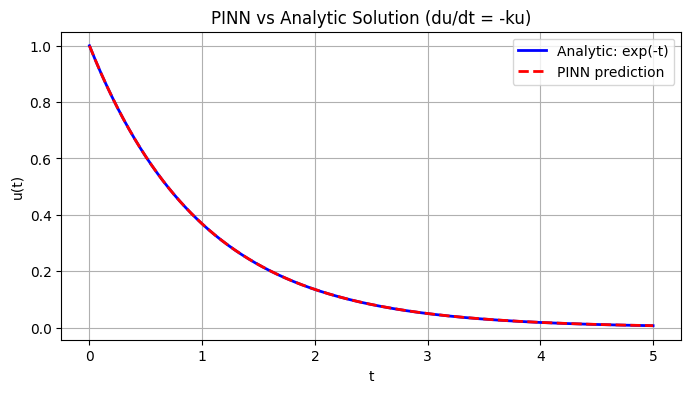

MSE vs analytic: 0.000000


In [ ]:
t_test = torch.linspace(0, T_end, 500).reshape(-1, 1).to(device)
with torch.no_grad():
    u_pred = model(t_test).cpu().numpy()
t_np = t_test.cpu().numpy()
u_analytic = np.exp(-k * t_np)

plt.figure(figsize=(8, 4))
plt.plot(t_np, u_analytic, 'b-', label='Analytic: exp(-t)', linewidth=2)
plt.plot(t_np, u_pred, 'r--', label='PINN prediction', linewidth=2)
plt.xlabel('t')
plt.ylabel('u(t)')
plt.title('PINN vs Analytic Solution (du/dt = -ku)')
plt.legend()
plt.grid(True)
plt.show()

mse = np.mean((u_pred - u_analytic)**2)
print(f'MSE vs analytic: {mse:.6f}')

## 6. Plot Loss History

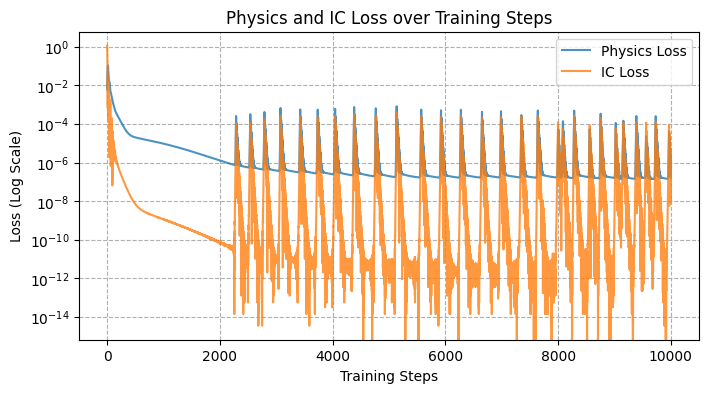

In [ ]:
# --- TODO: Plot physics loss and IC loss over training steps ---
plt.figure(figsize=(8, 4))
plt.semilogy(loss_history['physics'], label='Physics Loss', alpha=0.8)
plt.semilogy(loss_history['ic'], label='IC Loss', alpha=0.8)
plt.yscale('log')  # Dùng thang đo logarit để dễ nhìn sự biến thiên
plt.xlabel('Training Steps')
plt.ylabel('Loss (Log Scale)')
plt.title('Physics and IC Loss over Training Steps')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

## 7. Ablation: Loss Weights

*(Complete as part of Week 5 assignment)*

Rerun training with different weight settings and fill in the table:

| W_PHYSICS | W_IC | Final MSE vs analytic |
|-----------|------|----------------------|
| 1.0 | 1.0 |  0.000040 |
| 1.0 | 10.0 |  0.000000 |
